### 1. Setup & Imports

In [1]:
!pip install --force-reinstall pillow==10.1.0
!pip install facenet-pytorch
!pip install efficientnet_pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 24.5 MB/s eta 0:00:00
  Attempting uninstall: pillow
    Found existing installation: pillow 11.3.0
    Uninstalling pillow-11.3.0:
      Successfully uninstalled pillow-11.3.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 56.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 107.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 116.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 88.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 58.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.

  Preparing metadata (setup.py) ... done
  Created wheel for efficientnet_pytorch: filename=efficientnet_pytorch-0.7.1-py3-none-any.whl size=16426 sha256=137b6974cd65b30f70922285a412ef71bd145a2cd55d297242f408797679c27b
  Stored in directory: /root/.cache/pip/wheels/9c/3f/43/e6271c7026fe08c185da2be23c98c8e87477d3db63f41f32ad
Successfully built efficientnet_pytorch


In [1]:
import tarfile
import os
import cv2
import torch
from facenet_pytorch import MTCNN
from tqdm import tqdm
from PIL import Image
import random
import matplotlib.pyplot as plt
import shutil
from sklearn.model_selection import train_test_split
import torch.nn as nn
from efficientnet_pytorch import EfficientNet
import torch.optim as optim
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import timm


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
base_path = '/content/drive/My Drive/deepfake dataset'
extract_base_path = '/content/deepfake_data'

os.makedirs(extract_base_path, exist_ok=True)

tar_files = ['train.tar', 'test.tar', 'val.tar']

In [4]:
for tar_file in tar_files:
    tar_path = os.path.join(base_path, tar_file)
    extract_path = os.path.join(extract_base_path, tar_file.replace('.tar', ''))

    os.makedirs(extract_path, exist_ok=True)

    print(f'Extracting {tar_file}...')
    with tarfile.open(tar_path, 'r') as tar:
        tar.extractall(path=extract_path)
    print(f'Done extracting to {extract_path}')

Extracting train.tar...


/tmp/ipython-input-280043856.py:9: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_path)


Done extracting to /content/deepfake_data/train
Extracting test.tar...
Done extracting to /content/deepfake_data/test
Extracting val.tar...
Done extracting to /content/deepfake_data/val


In [5]:
base_path = '/content/drive/My Drive/deepfake dataset'
extract_base_path = '/content/deepfake_data'

os.makedirs(extract_base_path, exist_ok=True)

tar_files = ['train.tar', 'test.tar', 'val.tar']

In [6]:
train_path = '/content/deepfake_data/train'
test_path = '/content/deepfake_data/test'
val_path = '/content/deepfake_data/val'

print(os.listdir(train_path)[:5])

['real', 'fake']


In [7]:
import os

def print_directory_structure(root_dir, max_files=5, indent=""):
    """
    Recursively print the directory structure and a sample of files.

    Args:
        root_dir (str): Root directory to start listing from.
        max_files (int): Maximum number of files to display per directory.
        indent (str): Indentation for formatting output.
    """
    if not os.path.exists(root_dir):
        print(f"{indent}Directory {root_dir} does not exist.")
        return

    print(f"{indent}{root_dir}/")
    try:
        items = os.listdir(root_dir)
        for item in sorted(items):
            item_path = os.path.join(root_dir, item)
            if os.path.isdir(item_path):
                # Recursively print subdirectory
                print_directory_structure(item_path, max_files, indent + "  ")
            else:
                # Print file (limit to max_files per directory)
                if max_files > 0:
                    print(f"{indent}  {item}")
                    max_files -= 1
                elif max_files == 0:
                    print(f"{indent}  ... (more files)")
                    max_files -= 1
    except Exception as e:
        print(f"{indent}  Error accessing {root_dir}: {e}")

# Define the directories to inspect
dirs_to_check = [
    '/content/deepfake_data',
    '/content/processed_deepfake_frames',
    '/content/drive/My Drive/deepfake dataset'
]

# Print structure for each directory
for dir_path in dirs_to_check:
    print(f"\nStructure of {dir_path}:")
    print_directory_structure(dir_path)


Structure of /content/deepfake_data:
/content/deepfake_data/
  /content/deepfake_data/test/
    /content/deepfake_data/test/fake/
      01_09__hugging_happy__SJZRV69J.mp4
      01_11__exit_phone_room__9229VVZ3.mp4
      01_14__walking_outside_cafe_disgusted__01YF7VQM.mp4
      01_15__walking_and_outside_surprised__02HILKYO.mp4
      01_20__meeting_serious__FW94AIMJ.mp4
      ... (more files)
    /content/deepfake_data/test/real/
      01__secret_conversation.mp4
      01__talking_against_wall.mp4
      01__walking_outside_cafe_disgusted.mp4
      02__hugging_happy.mp4
      02__kitchen_still.mp4
      ... (more files)
  /content/deepfake_data/train/
    /content/deepfake_data/train/fake/
      01_02__exit_phone_room__YVGY8LOK.mp4
      01_02__hugging_happy__YVGY8LOK.mp4
      01_02__meeting_serious__YVGY8LOK.mp4
      01_02__secret_conversation__YVGY8LOK.mp4
      01_02__walking_down_indoor_hall_disgust__YVGY8LOK.mp4
      ... (more files)
    /content/deepfake_data/train/real/
      

### 2. Configuration & Hyperparameters

In [8]:
class Config:
    BATCH_SIZE = 16
    IMAGE_SIZE = 380  # EfficientNet-B4 standard size
    LR = 1e-4
    EPOCHS = 20
    NUM_CLASSES = 2
    DATA_PATH = '/content/processed_deepfake_frames'  # Point to processed frames
    USE_CUDA = torch.cuda.is_available()
    DEVICE = torch.device('cuda' if USE_CUDA else 'cpu')

config = Config()

### 3. Preprocessing & Data Pipeline

In [9]:
from torch.utils.data import Dataset
import os
from PIL import Image
import torch

class DeepfakeDualDataset(Dataset):
    def __init__(self, root_dir, transform_rgb, transform_dct=None):
        self.samples = []
        self.transform_rgb = transform_rgb
        self.transform_dct = transform_dct  # Unused for now
        for label in ['real', 'fake']:
            label_dir = os.path.join(root_dir, label)
            if not os.path.exists(label_dir):
                print(f"Warning: Directory {label_dir} does not exist. Skipping...")
                continue
            for fname in os.listdir(label_dir):
                if fname.endswith('.jpg'):
                    self.samples.append((
                        os.path.join(label_dir, fname),
                        None,  # No DCT data
                        0 if label == 'real' else 1
                    ))
        if not self.samples:
            raise RuntimeError(f"No valid samples found in {root_dir}. Check directory structure and file extensions.")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        rgb_path, _, label = self.samples[idx]
        img_rgb = Image.open(rgb_path).convert('RGB')
        if self.transform_rgb:
            img_rgb = self.transform_rgb(img_rgb)
        return img_rgb, img_rgb, torch.tensor(label).long()  # Return img_rgb twice to match model input

### 4. Transforms

In [10]:
train_transform = transforms.Compose([
    transforms.Resize((config.IMAGE_SIZE, config.IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.25, 0.25, 0.25, 0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225]),
])
val_transform = transforms.Compose([
    transforms.Resize((config.IMAGE_SIZE, config.IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225]),
])


### 5. Dataloaders

In [11]:
from torch.utils.data import Dataset
import os
from PIL import Image
import torch
import random

class DeepfakeDualDataset(Dataset):
    def __init__(self, root_dir, transform_rgb, transform_dct=None):
        self.samples = []
        self.transform_rgb = transform_rgb
        self.transform_dct = transform_dct  # Unused for now

        real_dir = os.path.join(root_dir, 'real')
        fake_dir = os.path.join(root_dir, 'fake')

        real_files = [os.path.join(real_dir, f) for f in os.listdir(real_dir) if f.endswith('.jpg')]
        fake_files = [os.path.join(fake_dir, f) for f in os.listdir(fake_dir) if f.endswith('.jpg')]

        min_len = min(len(real_files), len(fake_files))
        if min_len == 0:
            raise RuntimeError(f"Not enough data to balance real and fake in {root_dir}")

        real_sampled = random.sample(real_files, min_len)
        fake_sampled = random.sample(fake_files, min_len)

        self.samples.extend([(f, None, 0) for f in real_sampled])
        self.samples.extend([(f, None, 1) for f in fake_sampled])

        random.shuffle(self.samples)  # Shuffle to mix real and fake

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        rgb_path, _, label = self.samples[idx]
        img_rgb = Image.open(rgb_path).convert('RGB')
        if self.transform_rgb:
            img_rgb = self.transform_rgb(img_rgb)
        return img_rgb, img_rgb, torch.tensor(label).long()


In [12]:
# Paths
data_root = '/content/deepfake_data'
output_root = '/content/processed_deepfake_frames'
splits = ['train', 'val', 'test']
FRAMES_PER_VIDEO = 10

# Setup MTCNN for face detection
device = 'cuda' if torch.cuda.is_available() else 'cpu'
mtcnn = MTCNN(keep_all=False, device=device, image_size=224)

# Helper function to get evenly spaced frame indices
def get_frame_indices(total_frames, num_frames=10):
    if total_frames <= num_frames:
        return list(range(total_frames))
    step = total_frames // num_frames
    return [i * step for i in range(num_frames)]

# Process each split
for split in splits:
    split_root = os.path.join(data_root, split)
    split_output_root = os.path.join(output_root, split)
    os.makedirs(split_output_root, exist_ok=True)

    for label in ['real', 'fake']:
        input_dir = os.path.join(split_root, label)
        output_dir = os.path.join(split_output_root, label)
        os.makedirs(output_dir, exist_ok=True)

        videos = [f for f in os.listdir(input_dir) if f.lower().endswith(('.mp4', '.avi', '.mov'))]
        print(f"\nProcessing {len(videos)} {label} videos in {split} split...")

        for video_file in tqdm(videos, desc=f"{split}/{label}"):
            video_path = os.path.join(input_dir, video_file)
            cap = cv2.VideoCapture(video_path)
            total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            frame_indices = get_frame_indices(total_frames, FRAMES_PER_VIDEO)

            for i, frame_idx in enumerate(frame_indices):
                cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
                ret, frame = cap.read()
                if not ret:
                    continue
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frame_pil = Image.fromarray(frame)

                # Detect and crop face
                boxes, _ = mtcnn.detect(frame_pil)
                if boxes is not None:
                    box = boxes[0]
                    frame_pil = frame_pil.crop((box[0], box[1], box[2], box[3]))
                else:
                    continue  # Skip if no face detected

                # Save frame
                save_path = os.path.join(output_dir, f"{video_file}_frame_{i}.jpg")
                frame_pil.save(save_path)

            cap.release()
        print(f"Done processing {label} videos in {split} split.")


Processing 254 real videos in train split...


train/real: 100%|██████████| 254/254 [35:30<00:00,  8.39s/it]


Done processing real videos in train split.

Processing 700 fake videos in train split...


train/fake: 100%|██████████| 700/700 [1:36:56<00:00,  8.31s/it]


Done processing fake videos in train split.

Processing 54 real videos in val split...


...

Done processing fake videos in val split.

Processing 55 real videos in test split...


test/real: 100%|██████████| 55/55 [07:48<00:00,  8.52s/it]


Done processing real videos in test split.

Processing 150 fake videos in test split...


test/fake: 100%|██████████| 150/150 [20:38<00:00,  8.26s/it]

Done processing fake videos in test split.


In [13]:
train_set = DeepfakeDualDataset(os.path.join(config.DATA_PATH, 'train'), train_transform, train_transform)
val_set = DeepfakeDualDataset(os.path.join(config.DATA_PATH, 'val'), val_transform, val_transform)
test_set = DeepfakeDualDataset(os.path.join(config.DATA_PATH, 'test'), val_transform, val_transform)

train_loader = DataLoader(train_set, batch_size=config.BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_set, batch_size=config.BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_set, batch_size=config.BATCH_SIZE, shuffle=False, num_workers=2)


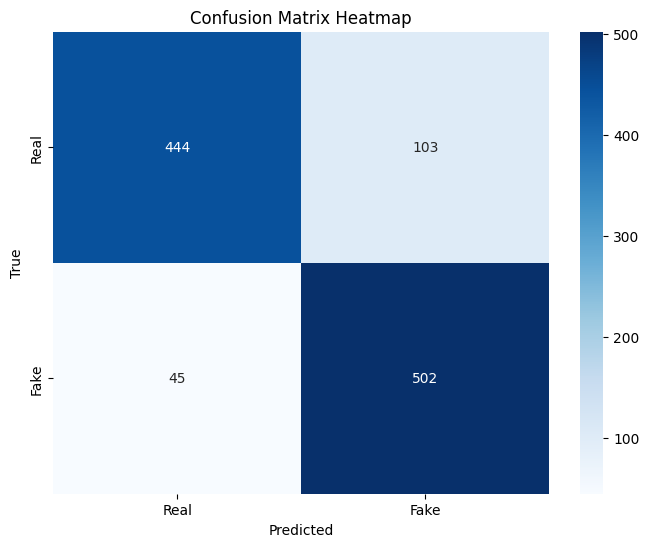

In [32]:
# Confusion Matrix Heatmap
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
import torch

model.eval()
y_true = []
y_pred = []
with torch.no_grad():
    for x_rgb, x_dct, y in test_loader:
        x_rgb = x_rgb.to(config.DEVICE)
        x_dct = x_dct.to(config.DEVICE)
        outputs = model(x_rgb, x_dct)
        _, predicted = torch.max(outputs.data, 1)
        y_true.extend(y.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix Heatmap')
plt.show()

### 6 Upgraded Model: EfficientNet-B4 + M2TR-Inspired Fusion

In [14]:
class M2TRModel(nn.Module):
    def __init__(self):
        super().__init__()
        # RGB stream: EfficientNet-B4 backbone
        self.rgb_model = EfficientNet.from_pretrained('efficientnet-b4')
        rgb_feat_dim = self.rgb_model._fc.in_features
        self.rgb_model._fc = nn.Identity()

        # Freq stream: ResNet18 backbone
        self.dct_model = timm.create_model('resnet18', pretrained=True, num_classes=0, global_pool='avg')
        dct_feat_dim = self.dct_model.num_features

        # Fusion head: Multi-head self-attention + classifier
        fusion_dim = rgb_feat_dim + dct_feat_dim
        self.att = nn.MultiheadAttention(fusion_dim, num_heads=4, batch_first=True)
        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, config.NUM_CLASSES)
        )
    def forward(self, x_rgb, x_dct):
        x1 = self.rgb_model.extract_features(x_rgb)
        x1 = nn.AdaptiveAvgPool2d(1)(x1).flatten(1)
        x2 = self.dct_model(x_dct)
        x = torch.cat([x1, x2], dim=1).unsqueeze(1)  # Add sequence dim
        x_att, _ = self.att(x, x, x)
        x = x_att.squeeze(1)
        return self.classifier(x)


### 7. Training Loop

In [15]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct = 0, 0
    for x_rgb, x_dct, y in tqdm(loader):
        x_rgb, x_dct, y = x_rgb.to(config.DEVICE), x_dct.to(config.DEVICE), y.to(config.DEVICE)
        optimizer.zero_grad()
        out = model(x_rgb, x_dct)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x_rgb.size(0)
        correct += (out.argmax(1) == y).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for x_rgb, x_dct, y in tqdm(loader):
            x_rgb, x_dct, y = x_rgb.to(config.DEVICE), x_dct.to(config.DEVICE), y.to(config.DEVICE)
            out = model(x_rgb, x_dct)
            loss = criterion(out, y)
            total_loss += loss.item() * x_rgb.size(0)
            correct += (out.argmax(1) == y).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)


### 8. Fit Model

In [16]:
model = M2TRModel().to(config.DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=config.LR)
criterion = nn.CrossEntropyLoss()

for epoch in range(5):
    print(f'Epoch {epoch+1}/5')
    tl, ta = train_epoch(model, train_loader, criterion, optimizer)
    vl, va = evaluate(model, val_loader, criterion)
    print(f'Train Loss: {tl:.4f} Acc: {ta:.4f} | Val Loss: {vl:.4f} Acc: {va:.4f}')



Downloading: "https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/efficientnet-b4-6ed6700e.pth" to /root/.cache/torch/hub/checkpoints/efficientnet-b4-6ed6700e.pth
100%|██████████| 74.4M/74.4M [00:00<00:00, 80.4MB/s]


Loaded pretrained weights for efficientnet-b4


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

Epoch 1/5


...

Train Loss: 0.1905 Acc: 0.9223 | Val Loss: 0.3665 Acc: 0.8699
Epoch 4/5


100%|██████████| 67/67 [00:19<00:00,  3.42it/s]


Train Loss: 0.1536 Acc: 0.9411 | Val Loss: 0.2883 Acc: 0.8951
Epoch 5/5


100%|██████████| 67/67 [00:19<00:00,  3.40it/s]

Train Loss: 0.1247 Acc: 0.9531 | Val Loss: 0.3506 Acc: 0.8773


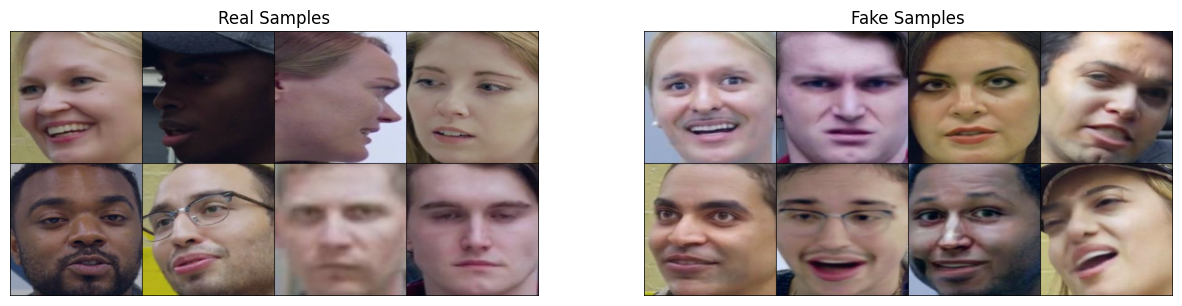

In [40]:
# Sample Images Grid (Real vs. Fake)
import torchvision.utils as vutils
import torch

data_iter = iter(test_loader)
x_rgb, x_dct, y = next(data_iter)
real_indices = (y == 0).nonzero(as_tuple=True)[0][:8]  # Assuming 0 = real
fake_indices = (y == 1).nonzero(as_tuple=True)[0][:8]  # Assuming 1 = fake

real_samples = x_rgb[real_indices]
fake_samples = x_rgb[fake_indices]

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.axis('off')
plt.title('Real Samples')
plt.imshow(vutils.make_grid(real_samples, nrow=4, normalize=True).permute(1, 2, 0))

plt.subplot(1, 2, 2)
plt.axis('off')
plt.title('Fake Samples')
plt.imshow(vutils.make_grid(fake_samples, nrow=4, normalize=True).permute(1, 2, 0))

plt.show()

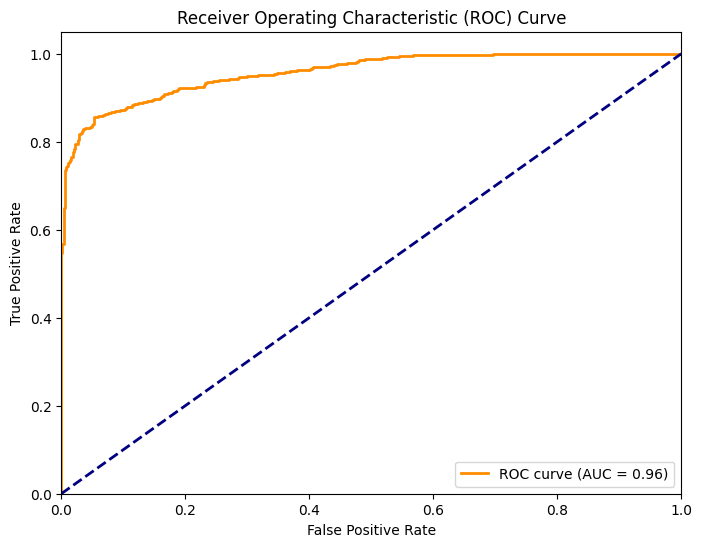

In [41]:
# ROC Curve
from sklearn.metrics import roc_curve, auc
import torch

model.eval()
y_true = []
y_scores = []
with torch.no_grad():
    for x_rgb, x_dct, y in test_loader:
        x_rgb = x_rgb.to(config.DEVICE)
        x_dct = x_dct.to(config.DEVICE)
        outputs = model(x_rgb, x_dct)
        probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()  # Probability of 'fake' class
        y_true.extend(y.cpu().numpy())
        y_scores.extend(probs)

fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

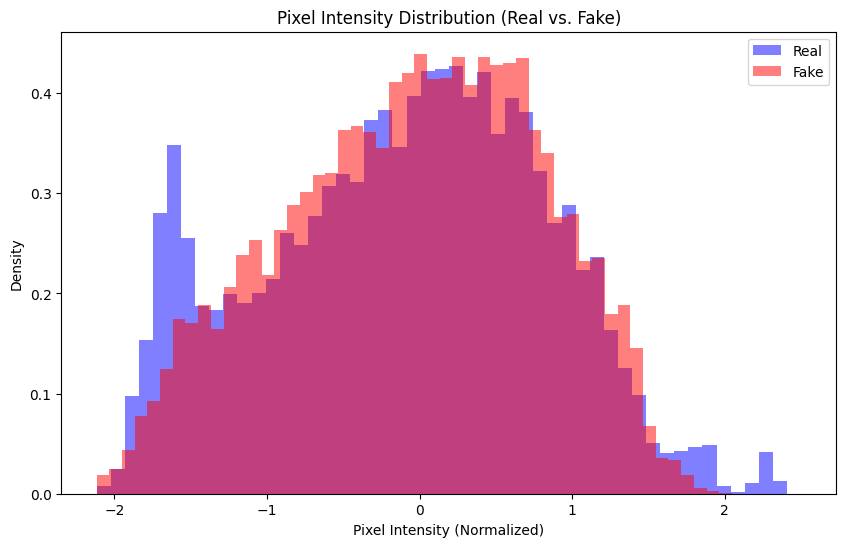

In [42]:
# Histogram of Pixel Intensities (Real vs. Fake)
import numpy as np
import matplotlib.pyplot as plt

data_iter = iter(test_loader)
x_rgb, _, y = next(data_iter)
real_pixels = x_rgb[y == 0].view(-1).cpu().numpy()  # Flatten all real images
fake_pixels = x_rgb[y == 1].view(-1).cpu().numpy()  # Flatten all fake images

plt.figure(figsize=(10, 6))
plt.hist(real_pixels, bins=50, alpha=0.5, label='Real', color='blue', density=True)
plt.hist(fake_pixels, bins=50, alpha=0.5, label='Fake', color='red', density=True)
plt.title('Pixel Intensity Distribution (Real vs. Fake)')
plt.xlabel('Pixel Intensity (Normalized)')
plt.ylabel('Density')
plt.legend()
plt.show()

### 9. Test & Metrics

In [17]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

def test_metrics(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x_rgb, x_dct, y in loader:
            x_rgb, x_dct = x_rgb.to(config.DEVICE), x_dct.to(config.DEVICE)
            out = model(x_rgb, x_dct)
            pred = out.argmax(1).cpu()
            all_preds.append(pred)
            all_labels.append(y)
    preds = torch.cat(all_preds)
    labels = torch.cat(all_labels)
    print('Classification Report:\n', classification_report(labels, preds, target_names=['Real','Fake']))
    print('Confusion Matrix:\n', confusion_matrix(labels, preds))
    if len(set(labels.numpy()))==2:
        print('ROC AUC:', roc_auc_score(labels, preds))


In [19]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

def test_metrics(model, loader):
    model.eval()
    all_preds, all_labels = [], []

    print("➡️ Starting evaluation ...")
    with torch.no_grad():
        batch_count = 0
        for x_rgb, x_dct, y in loader:
            batch_count += 1
            x_rgb, x_dct = x_rgb.to(config.DEVICE), x_dct.to(config.DEVICE)
            out = model(x_rgb, x_dct)
            pred = out.argmax(1).cpu()
            all_preds.append(pred)
            all_labels.append(y)
        print(f"✅ Processed {batch_count} batches")

    if len(all_preds) == 0:
        print("⚠️ No data in loader! Check your dataloader.")
        return

    preds = torch.cat(all_preds)
    labels = torch.cat(all_labels)

    print("\n📊 Classification Report:")
    print(classification_report(labels, preds, target_names=['Real','Fake']))

    print("\n🧾 Confusion Matrix:")
    print(confusion_matrix(labels, preds))

    if len(set(labels.numpy())) == 2:
        print("\n🔹 ROC AUC:", roc_auc_score(labels, preds))
    else:
        print("\n Only one class detected, skipping ROC AUC.")

test_metrics(model, test_loader)


➡️ Starting evaluation ...
✅ Processed 69 batches

📊 Classification Report:
              precision    recall  f1-score   support

        Real       0.91      0.81      0.86       547
        Fake       0.83      0.92      0.87       547

    accuracy                           0.86      1094
   macro avg       0.87      0.86      0.86      1094
weighted avg       0.87      0.86      0.86      1094


🧾 Confusion Matrix:
[[444 103]
 [ 45 502]]

🔹 ROC AUC: 0.8647166361974407


### 10. Grad-CAM Visualization

In [23]:
#  Grad-CAM Implementation (RGB stream only)
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.model.eval()
        self.hook_layers()

    def hook_layers(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()
        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()

        modules = dict(self.model.named_modules())
        if self.target_layer not in modules:
            raise ValueError(f"Layer {self.target_layer} not found. Available: {list(modules.keys())[:20]} ...")
        target_layer = modules[self.target_layer]
        target_layer.register_forward_hook(forward_hook)
        target_layer.register_backward_hook(backward_hook)
        print(f"✅ Hooked Grad-CAM on layer: {self.target_layer}")

    def generate(self, x_rgb, x_dct, class_idx):
        self.model.zero_grad()
        output = self.model(x_rgb.unsqueeze(0), x_dct.unsqueeze(0))
        target = output[0, class_idx]
        target.backward()

        gradients = self.gradients[0].cpu().numpy()
        activations = self.activations[0].cpu().numpy()
        weights = np.mean(gradients, axis=(1, 2))
        cam = np.sum(weights[:, None, None] * activations, axis=0)
        cam = np.maximum(cam, 0)
        cam = cv2.resize(cam, (config.IMG_SIZE, config.IMG_SIZE))
        if cam.max() != 0:
            cam = cam / cam.max()
        return cam

def gradcam_visualize(model, x_rgb, x_dct, y, save_path=None):
    grad_cam = GradCAM(model, 'rgb_model._conv_head')
    class_idx = y.item() if isinstance(y, torch.Tensor) else int(y)
    cam = grad_cam.generate(x_rgb, x_dct, class_idx)

    img = x_rgb.cpu().numpy().transpose(1, 2, 0)
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(img)
    plt.imshow(cam, cmap='jet', alpha=0.5)
    plt.title(f'Grad-CAM (Class: {"Real" if class_idx == 0 else "Fake"})')
    plt.axis('off')

    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
        print(f"💾 Grad-CAM saved to {save_path}")

    plt.show()
    plt.close()


In [28]:
#  Grad-CAM Implementation (RGB stream only)
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.model.eval()
        self.hook_layers()

    def hook_layers(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()
        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()

        modules = dict(self.model.named_modules())
        if self.target_layer not in modules:
            raise ValueError(f"Layer {self.target_layer} not found. "
                             f"Available: {list(modules.keys())[:20]} ...")
        target_layer = modules[self.target_layer]
        target_layer.register_forward_hook(forward_hook)
        target_layer.register_backward_hook(backward_hook)
        print(f"✅ Hooked Grad-CAM on layer: {self.target_layer}")

    def generate(self, x_rgb, x_dct, class_idx):
        self.model.zero_grad()
        output = self.model(x_rgb.unsqueeze(0), x_dct.unsqueeze(0))
        target = output[0, class_idx]
        target.backward()

        gradients = self.gradients[0].cpu().numpy()
        activations = self.activations[0].cpu().numpy()
        weights = np.mean(gradients, axis=(1, 2))
        cam = np.sum(weights[:, None, None] * activations, axis=0)
        cam = np.maximum(cam, 0)


        h, w = x_rgb.shape[1], x_rgb.shape[2]  # (C, H, W)
        cam = cv2.resize(cam, (w, h))

        if cam.max() != 0:
            cam = cam / cam.max()
        return cam

def gradcam_visualize(model, x_rgb, x_dct, y):
    grad_cam = GradCAM(model, 'rgb_model._conv_head')
    class_idx = y.item() if isinstance(y, torch.Tensor) else int(y)
    cam = grad_cam.generate(x_rgb, x_dct, class_idx)

    img = x_rgb.cpu().numpy().transpose(1, 2, 0)
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(img)
    plt.imshow(cam, cmap='jet', alpha=0.5)
    plt.title(f'Grad-CAM (Class: {"Real" if class_idx == 0 else "Fake"})')
    plt.axis('off')

    plt.show()


✅ Hooked Grad-CAM on layer: rgb_model._conv_head


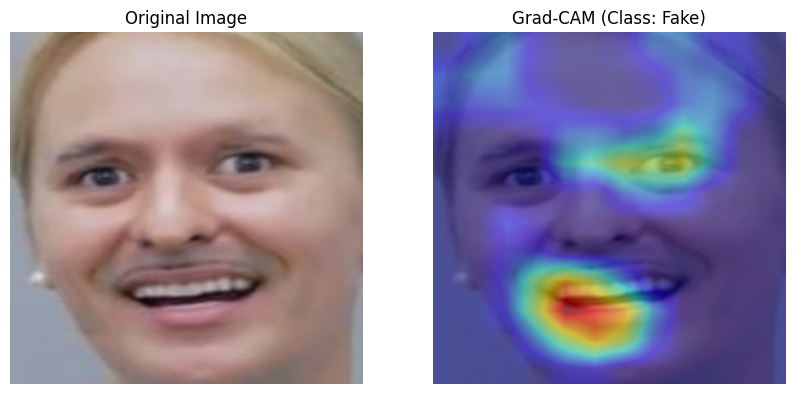

In [29]:
x_rgb, x_dct, y = next(iter(test_loader))
gradcam_visualize(model, x_rgb[0].to(config.DEVICE), x_dct[0].to(config.DEVICE), y[0])

In [30]:
def gradcam_visualize(model, x_rgb, x_dct, y):
    grad_cam = GradCAM(model, 'rgb_model._conv_head')
    class_idx = y.item() if isinstance(y, torch.Tensor) else int(y)
    cam = grad_cam.generate(x_rgb, x_dct, class_idx)

    img = x_rgb.cpu().numpy().transpose(1, 2, 0)
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)

    # Heatmap
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0

    # Overlay images
    overlay_strong = np.clip(heatmap * 0.7 + img * 0.3, 0, 1)  # more heatmap
    overlay_soft   = np.clip(heatmap * 0.4 + img * 0.6, 0, 1)  # softer blend

    plt.figure(figsize=(16, 6))

    plt.subplot(1, 4, 1)
    plt.imshow(img)
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 4, 2)
    plt.imshow(cam, cmap='jet')
    plt.title('Grad-CAM Heatmap')
    plt.axis('off')

    plt.subplot(1, 4, 3)
    plt.imshow(overlay_strong)
    plt.title('Overlay (Strong Heatmap)')
    plt.axis('off')

    plt.subplot(1, 4, 4)
    plt.imshow(overlay_soft)
    plt.title('Overlay (Soft Heatmap)')
    plt.axis('off')

    plt.suptitle(f'Grad-CAM Visualizations (Class: {"Real" if class_idx == 0 else "Fake"})',
                 fontsize=14, y=1.05)
    plt.tight_layout()
    plt.show()


✅ Hooked Grad-CAM on layer: rgb_model._conv_head


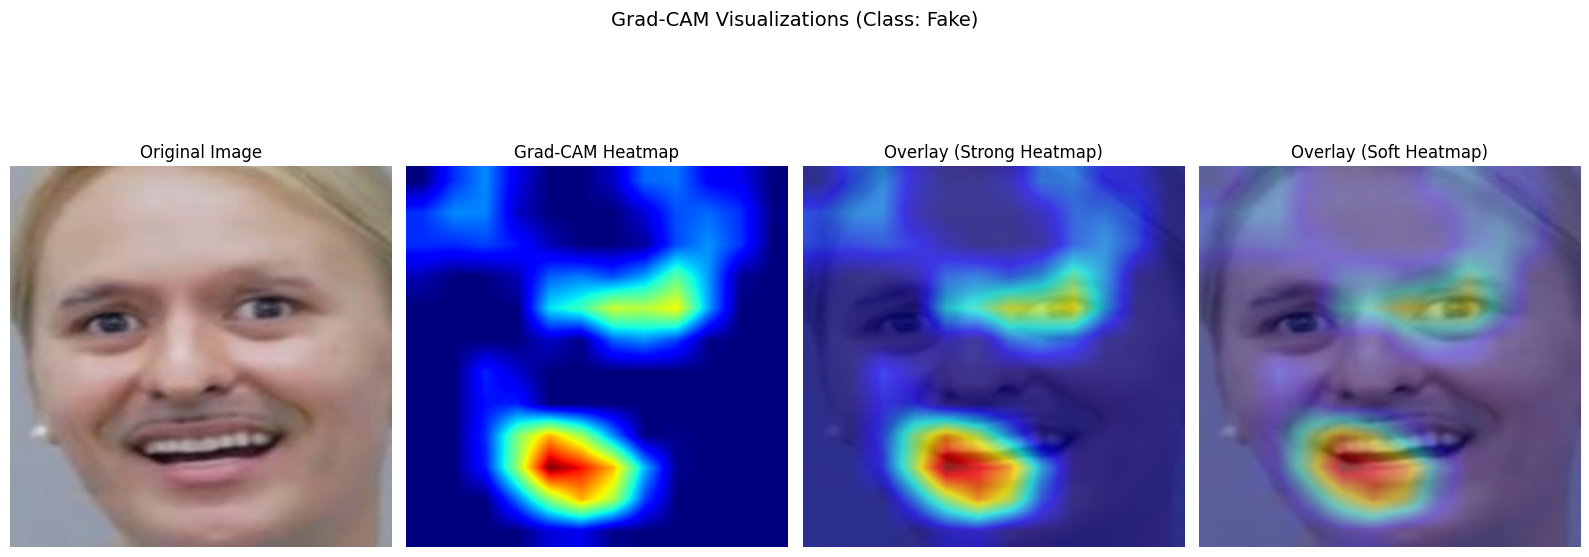

In [31]:
x_rgb, x_dct, y = next(iter(test_loader))
gradcam_visualize(model, x_rgb[0].to(config.DEVICE), x_dct[0].to(config.DEVICE), y[0])
